# Goals for Exploration
* Find any missing/strange data.
* Figure out how to handle returns/negative quantity.

# Cohort Analysis
* Grouping: First purchase month

# Preparation
* Create quintiles for Recency, Frequency, and Monetary Value

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [90]:
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df1, df2])

# Cleaning and Filtering
* Non-UK customers (~9% of the dataset) are removed to avoid any edge cases related to geography. Perhaps some customers purchase an item wholesale because it was easier to buy it from a British company rather than locally, for example.
* Removed rows where Customer IDs are missing because they are not relevant. Many are also just instances of inventory being thrown away or something similar.
* Returns (negative quantity entries) will not be counted for time-based metrics like retention and purchase frequency, however they will be included for revenue.

In [91]:
df = df[pd.notna(df['Customer ID'])]
df['Revenue'] = df['Price'] * df['Quantity']

In [ ]:
# Calculate average revenue per customer
customer_avg_revenue = df.groupby('Customer ID')['Revenue'].mean().reset_index()
customer_avg_revenue.columns = ['Customer ID', 'AvgRevenue']


# Cohort Analysis

I need to set up the Cohort Analysis by creating a column for the first month of purchase, frequency of purchasing, and spending per order.

For the first month of purchase, I'll need to manipulate the dates so I can grab just the year and month (to be stored as 'InvoiceMonth') since they also include the day and time. Then, I will have to find the earliest month of purchase based on the months/years that will be stored as 'CohortMonth'. From there I will create an index for each cohort based on how many months it has been since their first purchase. 

I will also remove any refunds (Quantity < 0) so they do not appear in the heat map later on.


<Axes: xlabel='Cohort Index', ylabel='Cohort Month'>

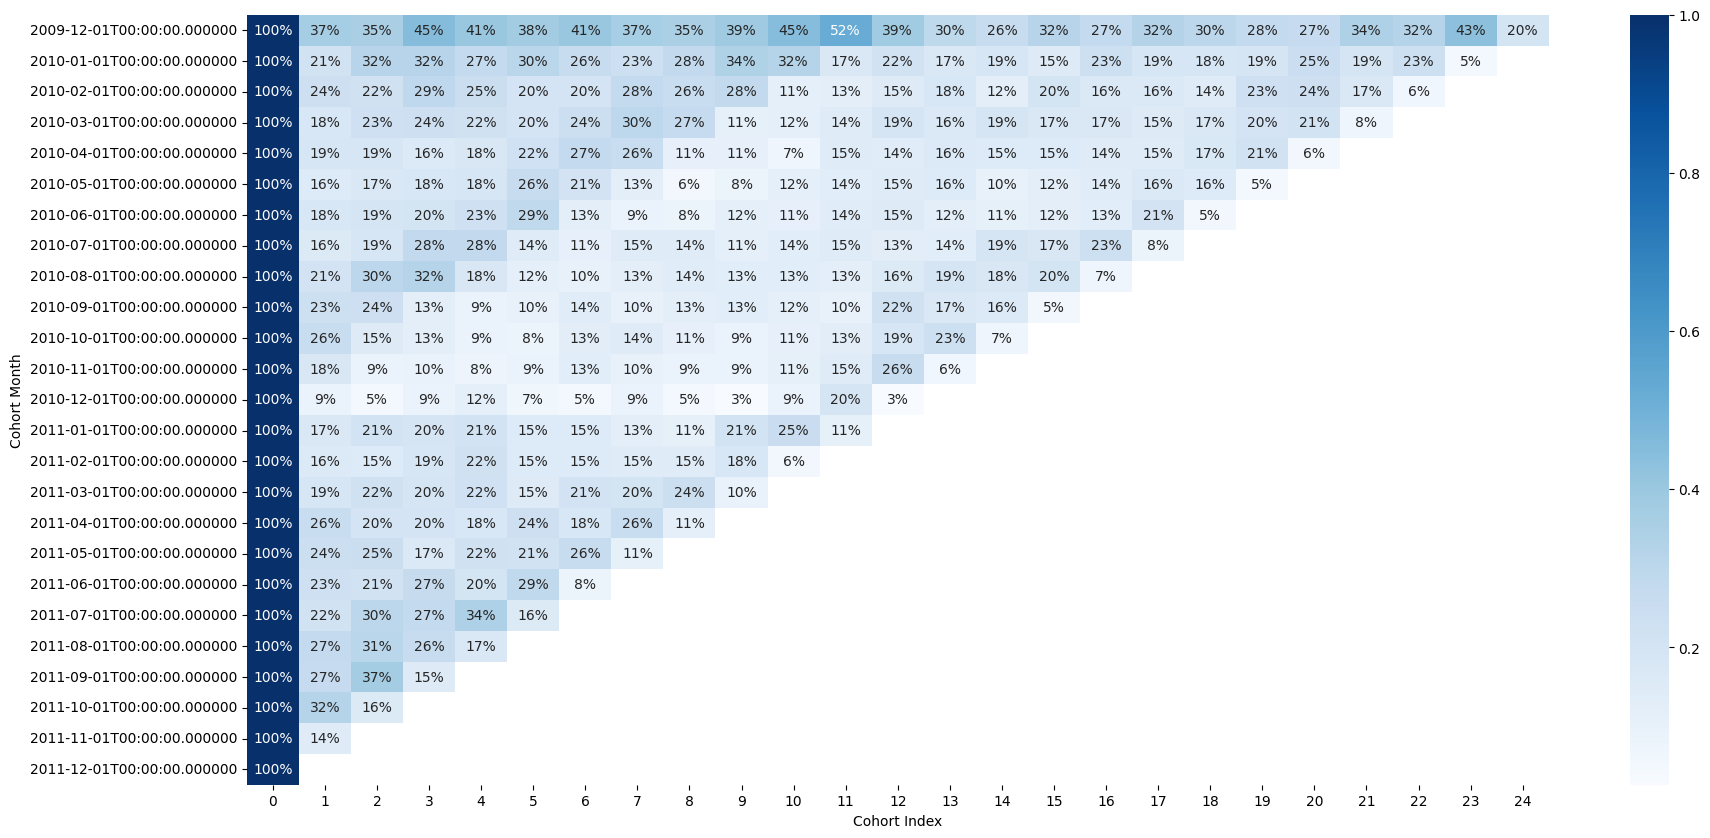

In [118]:
import datetime as dt

def get_month(date):
    # grabs the month and year for all of a month's invoices to be consolidated into the first day of the month
    return dt.datetime(date.year, date.month, 1)

df['Invoice Month'] = df['InvoiceDate'].apply(get_month)
df['Cohort Month'] = df.groupby('Customer ID')['Invoice Month'].transform('min')

def adjust_months(days):
    # Arbitrarily decides if the days are close enough to be rounded up to the next month
    # 30 is arbitrarily chose to be a month (there is not real objective month timeframe), and 20 is also arbitrarily chosen because it's close-ish to 30.
    # 20 can really be any number
    months, remainder = divmod(days,30)
    if remainder >= 20:
        return months + 1
    else:
        return months
    
def get_time_delta(df, column1, column2):
    # After a simple subtraction, use adjust_months to determine if the remainder is close enough to a full month to round
    days = (df[column1] - df[column2]).dt.days
    adjusted_months = days.map(adjust_months)
    return adjusted_months

adjusted_months = get_time_delta(df, 'Invoice Month', 'Cohort Month')
df['Cohort Index'] = adjusted_months

#Cohort Heat map
cohort_data = df[df['Quantity'] > 0].groupby(['Cohort Month','Cohort Index'])['Customer ID'].apply(pd.Series.nunique).reset_index()
cohort_table = cohort_data.pivot(index='Cohort Month', columns=['Cohort Index'],values='Customer ID')
cohort_table = cohort_table.divide(cohort_table.iloc[:,0], axis=0)
plt.figure(figsize=(21,10))
sns.heatmap(cohort_table,annot=True,fmt='.0%', cmap='Blues')

There are some interesting points:
* The first cohort is especially consistent.
* There is a strange paralellogram with a base at the 2010-12-01 00:00:00 cohort where there is a noticable decrease in consistency (between 0 and 20%), which the cohorts eventually recovered from to get to the 20-30% retention rate that is more typical for other cohorts. Even weirder, the cohorts after do not even seem to have this effect at all.
* The last entry is lower than expected because the data does not extend to December 31st, and in fact ends on December 9th. So, the values are expected to be around three times higher.

Some things to do:
* Look at the 2009-12-01 00:00:00 and 2010-12-01 00:00:00 cohorts to see if there is anything strange about it. The former is especially loyal, and the latter is especially sporadic.
* Look at the history of prices to try to explain the parallelogram.

## Finding some new features
Before really digging into the data, I want to:
* Establish quintiles (arbitrary, but the Investopedia article suggested quintiles) for RFM (recency, frequency, and monetary value).
** The means calculating the following:
*** Recency: days since last purchase. 
*** Frequency: total number of invoices
*** Monetary Value: total revenue generated (perhaps it should be averaged by total purchases?)
** This should also give some insight into the customers which entered into each cohort. I figure that 2009-12 had particularly highly rated customers, while 2010-12 had relatviely lowly rated customers.

In [171]:
recency = df.groupby(by='Customer ID', as_index=False)['InvoiceDate'].max()
recency.columns = ['Customer ID', 'Last Purchase Date']
last_date = recency['Last Purchase Date'].max()
recency['Recency'] = recency['Last Purchase Date'].apply(lambda x: (last_date - x).days)

frequency = df.groupby(by='Customer ID', as_index=False)['InvoiceDate'].count()
frequency.columns = ['Customer ID', 'Frequency']

monetary_value = df.groupby(by='Customer ID', as_index=False)['Revenue'].sum()
monetary_value.columns = ['Customer ID', 'Monetary Value']

rf_df = recency.merge(frequency, on='Customer ID')
rfm_df = rf_df.merge(monetary_value, on='Customer ID').drop(columns='Last Purchase Date')

rfm_df['Recency Quintile'] = pd.qcut(x=rfm_df['Recency'], q=5, labels=[5,4,3,2,1]).astype(np.int64)
rfm_df['Frequency Quintile'] = pd.qcut(x=rfm_df['Frequency'], q=5, labels=[1,2,3,4,5]).astype(np.int64)
rfm_df['Monetary Value Quintile'] = pd.qcut(x=rfm_df['Monetary Value'], q=5, labels=[1,2,3,4,5]).astype(np.int64)

rfm_df['Avg RFM Score'] = (rfm_df['Recency Quintile'] + rfm_df['Frequency Quintile'] + rfm_df['Monetary Value Quintile']) / 3
rfm_df.drop(["Recency", "Frequency", "Monetary Value"], axis=1)


,Customer ID,Recency Quintile,Frequency Quintile,Monetary Value Quintile,Avg RFM Score
0,12346.0,2,3,1,2.000000
1,12347.0,5,5,5,5.000000
2,12348.0,3,3,4,3.333333
3,12349.0,4,4,5,4.333333
4,12350.0,2,2,2,2.000000
...,...,...,...,...,...
5937,18283.0,5,5,4,4.666667
5938,18284.0,1,2,2,1.666667
5939,18285.0,1,1,2,1.333333
5940,18286.0,1,3,4,2.666667


In [177]:
rfm_df[rfm_df['Avg RFM Score'] == 5].shape[0], rfm_df.shape[0]

(448, 5942)

In [179]:
cohort_2009_12_df = df[df['Cohort Month'] == '2009-12-01 00:00:00']
cohort_2010_12_df = df[df['Cohort Month'] == '2010-12-01 00:00:00']

In [211]:
unique_customers_2009 = cohort_2009_12_df['Customer ID'].drop_duplicates().reset_index().drop(columns='index')
rfm_cohort_2009_12_df = rfm_df.merge(right=unique_customers_2009,how='inner')
rfm_cohort_2009_12_df['Avg RFM Score'].mean()

np.float64(3.6807017543859653)

In [212]:
unique_customers_2010 = cohort_2010_12_df['Customer ID'].drop_duplicates().reset_index().drop(columns='index')
rfm_cohort_2010_12_df = rfm_df.merge(right=unique_customers_2010,how='inner')
rfm_cohort_2010_12_df['Avg RFM Score'].mean()

np.float64(2.6363636363636362)

There is substantial difference between the poorly performing cohort (2010-12) and the incredibly loyal (2009-12) cohort. Which is interesting and brings up the question of how do the cohorts rank in terms of average RFM score?

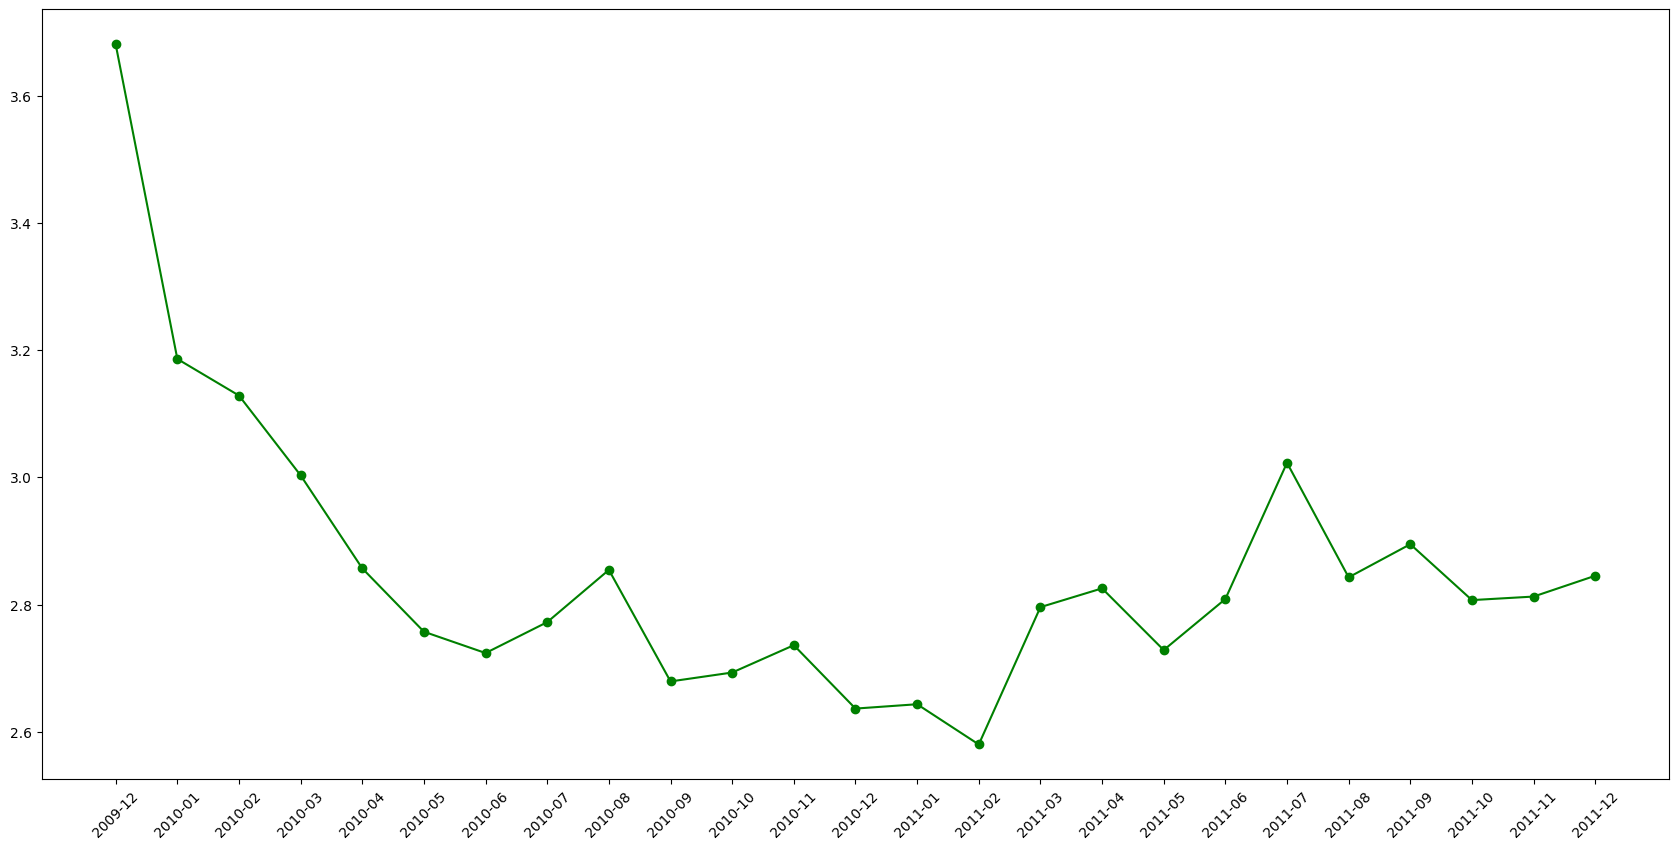

In [219]:
rfm_avg_dict = {}
for cohort in df['Cohort Month'].drop_duplicates():
    cohort_df = df[df['Cohort Month'] == cohort]
    unique_customers = cohort_df['Customer ID'].drop_duplicates().reset_index().drop(columns='index')
    rfm_cohort = rfm_df.merge(right=unique_customers,how='inner')
    rfm_avg_dict[str(cohort)[:7]]= rfm_cohort['Avg RFM Score'].mean()

plt.figure(figsize=(21,10))
plt.xticks(rotation=45)
plt.plot(rfm_avg_dict.keys(), rfm_avg_dict.values(), color='green', marker='o')

## Conclusions
Interestingly, 2010-12 was not even the lowest average RFM score, but it is amongst the lowest. The reason for this is likely because I gave each factor equal weight, but differing weights could capture this better and reflect reality more.

Regardless, this gives some insight into why certain cohorts seem better than other ones. The initial cohort does seem to be the best by a large margin, and the 2010-12 cohort is amongst the worst cohorts by this metric.

This doesn't really help explain the strange parallelogram of low retention, which lasted from January to October 2011 which only affected previous cohorts.

### Clustering

With the quintiles in 